# Market Basket Analysis: Online Retail Transaction
- **Dataset:** Online Retail Dataset (Dữ liệu giao dịch thực tế từ Anh quốc).
- **Mục tiêu:** Khai phá luật kết hợp (Association Rules) để tìm mối liên quan giữa các sản phẩm.
- **Thuật toán:** So sánh hiệu năng và sinh luật bằng Apriori và FP-Growth (sử dụng thư viện `mlxtend` và `pyfim`).

### 1. Setup & Data Loading
Cài đặt thư viện `pyfim` (C-engine) để tối ưu hiệu năng tính toán và tải tập dữ liệu gốc.

In [1]:
pip install pyfim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.3/357.3 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyfim: filename=pyfim-6.28-cp312-cp312-linux_x86_64.whl size=647322 sha256=c9711e8f96fe6105d7d1089498dc52cd38a9e3a38b0b6faa92c9963e8afd391d
  Stored in directory: /root/.cache/pip/wheels/4f/f8/fc/9c22754402de057faecaeb2bb88208898bb0c6eff5ffbfd618
Successfully built pyfim
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import os

path = '/kaggle/input/datasets/ulrikthygepedersen/online-retail-dataset/online_retail.csv' if os.path.exists('/kaggle') else 'online_retail.csv'
df = pd.read_csv(path, encoding='latin1')

print(f"Tổng số dòng (Transactions) - Trước: {len(df):,}")
print(f"Số lượng quốc gia - Trước: {df['Country'].nunique()}")
print(f"Số lượng sản phẩm duy nhất - Trước: {df['StockCode'].nunique():,}")

Tổng số dòng (Transactions) - Trước: 541,909
Số lượng quốc gia - Trước: 38
Số lượng sản phẩm duy nhất - Trước: 4,070


### 2. Data Cleaning & Preprocessing
Lọc bỏ các mã sản phẩm phi vật lý (POST, D, M,...) và các đơn hàng bị hủy. Chuẩn hóa mô tả sản phẩm và tạo ánh xạ mã - tên để dễ quan sát kết quả.

## Kiểm tra cơ cấu các quốc gia

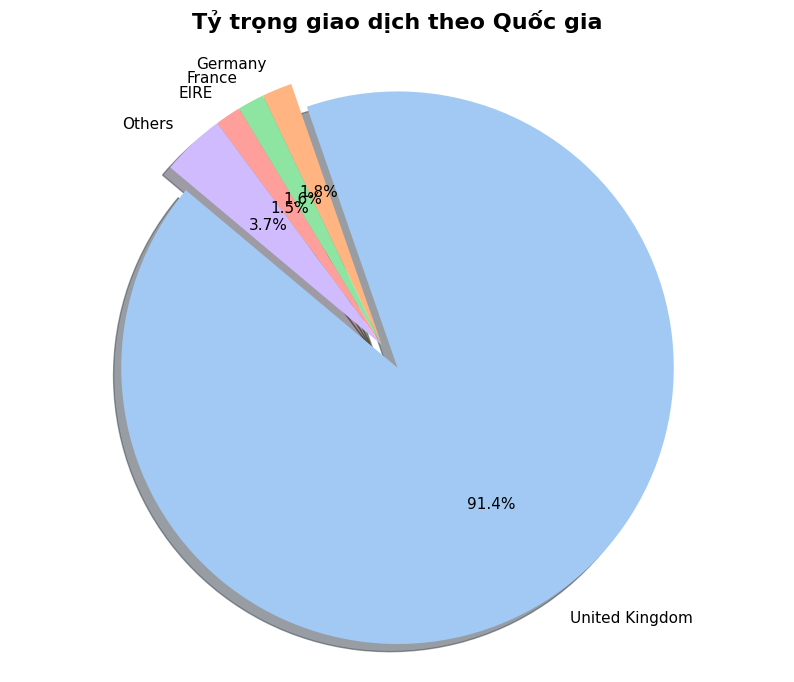

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# --- TỔNG QUAN VỀ QUỐC GIA (Overview EDA) ---
# Đếm số lượng dòng dữ liệu (hoặc giao dịch) của từng quốc gia
country_counts = df['Country'].value_counts()

# Tính ngưỡng 1% tổng số giao dịch
threshold = 0.01 * country_counts.sum()

# Tách nhóm các quốc gia lớn (>1%) và gom các quốc gia nhỏ (<1%) thành 'Others'
main_countries = country_counts[country_counts >= threshold]
other_countries_sum = country_counts[country_counts < threshold].sum()
other_countries = pd.Series([other_countries_sum], index=['Others'])

# Gộp dữ liệu để vẽ
plot_data = pd.concat([main_countries, other_countries])

# Vẽ biểu đồ Pie Chart
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:len(plot_data)]

# Tạo pie chart với shadow và explode để làm nổi bật UK
explode = [0.1 if index == 'United Kingdom' else 0 for index in plot_data.index]

plt.pie(plot_data, 
        labels=plot_data.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode,
        shadow=True,
        textprops={'fontsize': 11})

plt.title('Tỷ trọng giao dịch theo Quốc gia', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  # Đảm bảo biểu đồ tròn đều
plt.show()

In [4]:
# 1. Look for non-standard StockCodes (non-physical items)
# Standard stock codes are usually 5 digits, sometimes with a letter at the end.
# Let's find codes that are very short or purely alphabetical.
non_standard_codes = df[df['StockCode'].str.contains('^[A-Za-z]+$', regex=True, na=False)]['StockCode'].unique()
print("Non-standard StockCodes (purely alphabetical):", non_standard_codes)

# Let's check descriptions for these non-standard codes
for code in non_standard_codes:
    desc = df[df['StockCode'] == code]['Description'].unique()
    print(f"Code: {code}, Descriptions: {desc}")

# 2. Check Entity Identification (StockCode vs Description)
# How many StockCodes have multiple Descriptions?
stockcode_desc_counts = df.groupby('StockCode')['Description'].nunique()
codes_with_multiple_descs = stockcode_desc_counts[stockcode_desc_counts > 1]
print(f"\nNumber of StockCodes with >1 Description: {len(codes_with_multiple_descs)}")
if len(codes_with_multiple_descs) > 0:
    print("Example StockCodes with multiple descriptions:")
    example_code = codes_with_multiple_descs.index[0]
    print(f"Code {example_code}: {df[df['StockCode'] == example_code]['Description'].unique()}")

# How many Descriptions have multiple StockCodes?
desc_stockcode_counts = df.groupby('Description')['StockCode'].nunique()
descs_with_multiple_codes = desc_stockcode_counts[desc_stockcode_counts > 1]
print(f"\nNumber of Descriptions with >1 StockCode: {len(descs_with_multiple_codes)}")

Non-standard StockCodes (purely alphabetical): ['POST' 'D' 'DOT' 'M' 'S' 'AMAZONFEE' 'm' 'DCGSSBOY' 'DCGSSGIRL' 'PADS'
 'B' 'CRUK']
Code: POST, Descriptions: ['POSTAGE' nan]
Code: D, Descriptions: ['Discount']
Code: DOT, Descriptions: ['DOTCOM POSTAGE' nan]
Code: M, Descriptions: ['Manual']
Code: S, Descriptions: ['SAMPLES']
Code: AMAZONFEE, Descriptions: ['AMAZON FEE']
Code: m, Descriptions: ['Manual']
Code: DCGSSBOY, Descriptions: ['BOYS PARTY BAG']
Code: DCGSSGIRL, Descriptions: ['GIRLS PARTY BAG']
Code: PADS, Descriptions: ['PADS TO MATCH ALL CUSHIONS']
Code: B, Descriptions: ['Adjust bad debt']
Code: CRUK, Descriptions: ['CRUK Commission']

Number of StockCodes with >1 Description: 650
Example StockCodes with multiple descriptions:
Code 10080: ['GROOVY CACTUS INFLATABLE' nan 'check']

Number of Descriptions with >1 StockCode: 172


## Thống kê mô tả

In [5]:
df = df[df['Country'] == 'United Kingdom']

# --- THỐNG KÊ MÔ TẢ (Descriptive Statistics) ---

# 1. Thống kê cho các biến số (Quantity và UnitPrice)
print("1. Thống kê phân phối các biến định lượng (Quantity, UnitPrice):")
# Dùng hàm display() trong Jupyter Notebook để bảng hiện ra đẹp hơn print()
display(df[['Quantity', 'UnitPrice']].describe().round(2))

# 2. Các chỉ số tổng quan về quy mô tập dữ liệu (Market Basket)
print("\n2. Quy mô tập dữ liệu (Thị trường UK):")
total_invoices = df['InvoiceNo'].nunique()
total_items = df['StockCode'].nunique()
total_customers = df['CustomerID'].nunique() if 'CustomerID' in df.columns else "N/A"

print(f"- Tổng số đơn hàng (Transactions/Invoices): {total_invoices:,.0f}")
print(f"- Tổng số sản phẩm khác nhau (Unique Items): {total_items:,.0f}")
print(f"- Tổng số khách hàng (Unique Customers): {total_customers}")

# 3. Phân tích Giỏ hàng (Basket Analysis)
# Tạo cột Doanh thu từng dòng (Total Price)
if 'UnitPrice' in df.columns and 'Quantity' in df.columns:
    df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
    
    # Tính tổng giá trị và tổng số lượng sản phẩm của từng đơn hàng
    basket_summary = df.groupby('InvoiceNo').agg(
        Total_Value=('TotalPrice', 'sum'),
        Total_Items=('Quantity', 'sum'),
        Unique_Items=('StockCode', 'nunique')
    )
    
    print("\n3. Thống kê chi tiết trên từng Giỏ hàng (Mỗi Invoice là 1 giỏ):")
    display(basket_summary.describe().round(2))

1. Thống kê phân phối các biến định lượng (Quantity, UnitPrice):


,Quantity,UnitPrice
count,495478.00,495478.00
mean,8.61,4.53
std,227.59,99.32
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.13
max,80995.00,38970.00



2. Quy mô tập dữ liệu (Thị trường UK):
- Tổng số đơn hàng (Transactions/Invoices): 23,494
- Tổng số sản phẩm khác nhau (Unique Items): 4,065
- Tổng số khách hàng (Unique Customers): 3950

3. Thống kê chi tiết trên từng Giỏ hàng (Mỗi Invoice là 1 giỏ):


,Total_Value,Total_Items,Unique_Items
count,23494.00,23494.00,23494.00
mean,348.51,181.49,20.64
std,2045.67,1113.27,44.07
min,-168469.60,-80995.00,1.00
25%,8.50,6.00,2.00
50%,198.27,97.00,9.00
75%,388.21,231.00,23.00
max,168469.60,80995.00,1110.00


In [6]:


# --- DATA CLEANSING ---
df['Description'] = df['Description'].str.strip().str.upper()
df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)
df['InvoiceNo'] = df['InvoiceNo'].astype('str')
df = df[~df['InvoiceNo'].str.contains('C')]
df = df[df['Quantity'] > 0]
df = df[~df['StockCode'].str.contains('^[a-zA-Z]+$', regex=True)]

item_name_mapping = df.dropna(subset=['Description']).groupby('StockCode')['Description'].first().to_dict()

### 3. Data Transformation
Chuyển đổi dữ liệu từ dạng danh sách giao dịch sang ma trận thưa (One-hot encoding) theo số hóa đơn (InvoiceNo), tập trung vào thị trường United Kingdom.

In [7]:
# --- DATA TRANSFORMATION & AGGREGATION ---
import warnings
warnings.filterwarnings("ignore")
warnings.showwarning = lambda *args, **kwargs: None
basket = (df
          .groupby(['InvoiceNo', 'StockCode'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

def encode_units(x):
    return True if x >= 1 else False

basket_sets = basket.map(encode_units) 

print("=== SAU TIỀN XỬ LÝ (DỮ LIỆU SẠCH) ===")
print(f"Tổng số dòng (Transactions) : {len(df):,}")
print(f"Số lượng quốc gia           : {df['Country'].nunique()} (United Kingdom)")
print(f"Số lượng sản phẩm duy nhất  : {df['StockCode'].nunique():,}")

=== SAU TIỀN XỬ LÝ (DỮ LIỆU SẠCH) ===
Tổng số dòng (Transactions) : 485,203
Số lượng quốc gia           : 1 (United Kingdom)
Số lượng sản phẩm duy nhất  : 3,926


### 4. Exploratory Data Analysis (EDA)
Trực quan hóa 10 sản phẩm bán chạy nhất, phân phối kích thước giỏ hàng và xu hướng giao dịch theo thời gian để hiểu đặc điểm dữ liệu.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

Đang vẽ biểu đồ EDA...


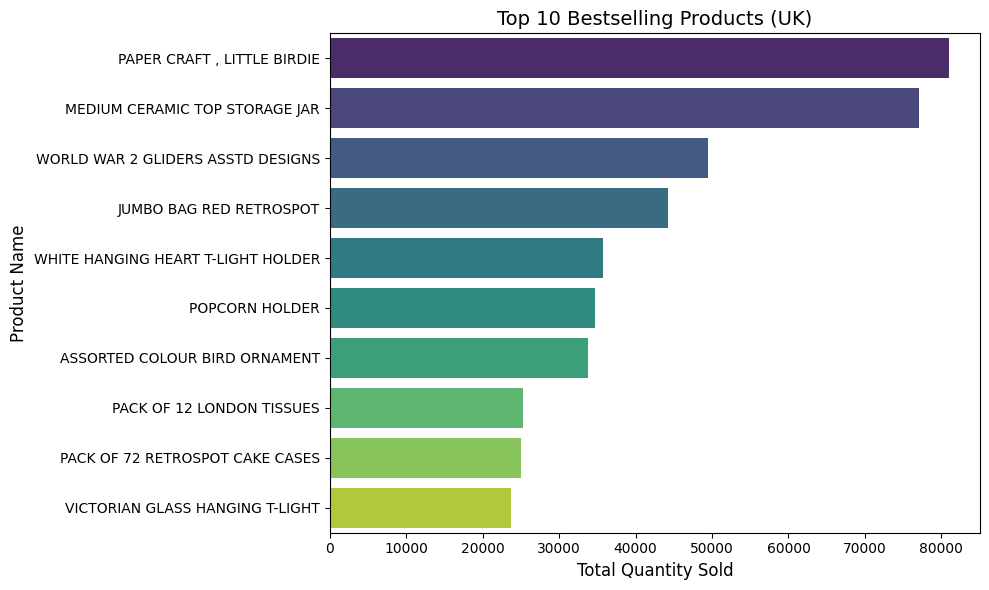

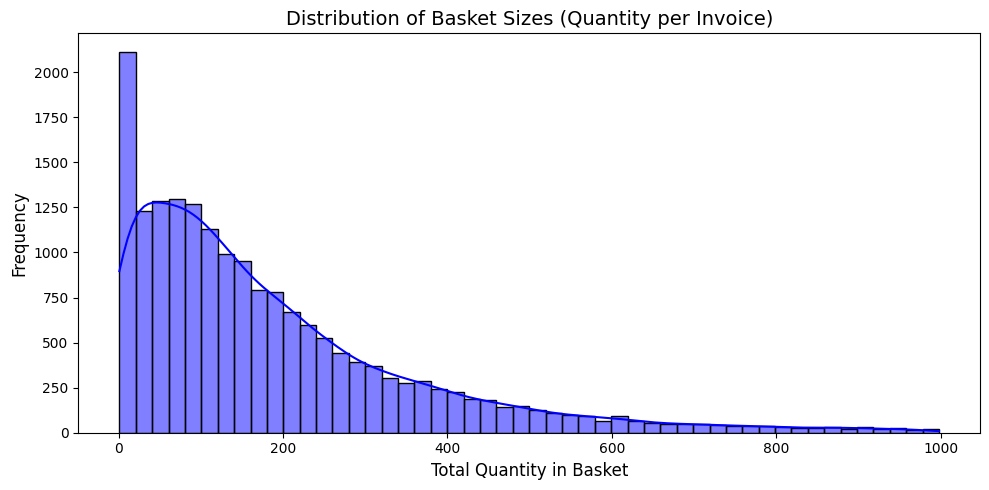

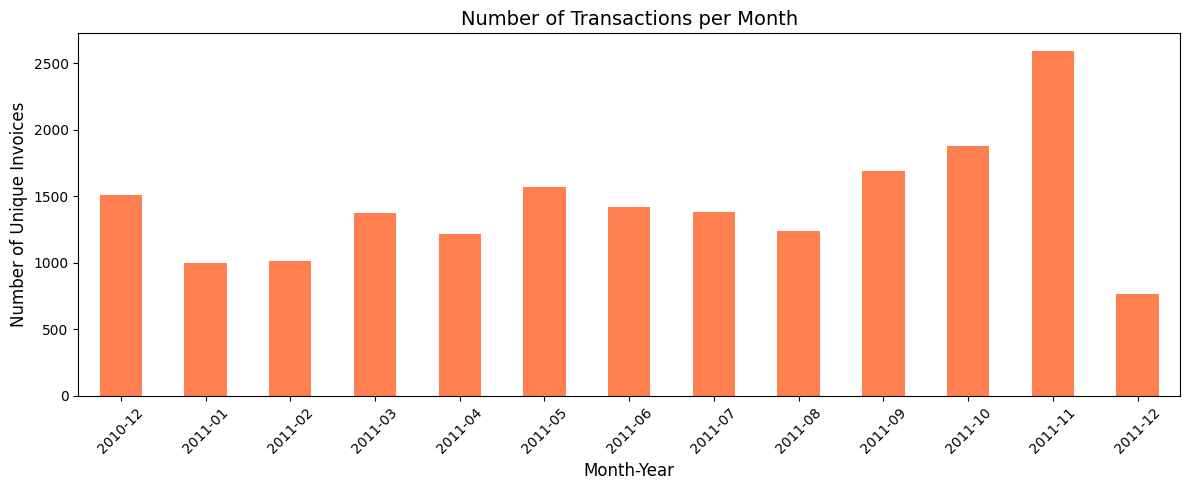

In [9]:
# --- KHÁM PHÁ DỮ LIỆU (EDA) ---
import warnings
warnings.filterwarnings("ignore")
warnings.showwarning = lambda *args, **kwargs: None
print("Đang vẽ biểu đồ EDA...")

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='viridis', legend=False)
plt.title('Top 10 Bestselling Products (UK)', fontsize=14)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

basket_sizes = df.groupby('InvoiceNo')['Quantity'].sum()
plt.figure(figsize=(10, 5))
sns.histplot(basket_sizes[basket_sizes < 1000], bins=50, kde=True, color='blue')
plt.title('Distribution of Basket Sizes (Quantity per Invoice)', fontsize=14)
plt.xlabel('Total Quantity in Basket', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['InvoiceNo'].nunique()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='bar', color='coral')
plt.title('Number of Transactions per Month', fontsize=14)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Unique Invoices', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Frequent Itemset Mining: Performance Benchmark
Thực hiện thực nghiệm so sánh tốc độ xử lý và mức độ chiếm dụng bộ nhớ của Apriori và FP-Growth (C-Engine) trên các mức Support khác nhau.

Đang chuẩn bị dữ liệu dạng List of Lists cho pyfim...
Đang chạy benchmark...
min_sup=0.002 | Apriori: 71.6941s / 3248.12MB | FP-Growth: 46.9600s / 2711.56MB
min_sup=0.003 | Apriori: 2.3524s / 31.39MB | FP-Growth: 1.6165s / 31.39MB
min_sup=0.004 | Apriori: 0.7219s / 6.23MB | FP-Growth: 0.6940s / 6.23MB
min_sup=0.006 | Apriori: 0.2696s / 1.21MB | FP-Growth: 0.3618s / 1.21MB
min_sup=0.008 | Apriori: 0.1796s / 0.52MB | FP-Growth: 0.2640s / 0.52MB


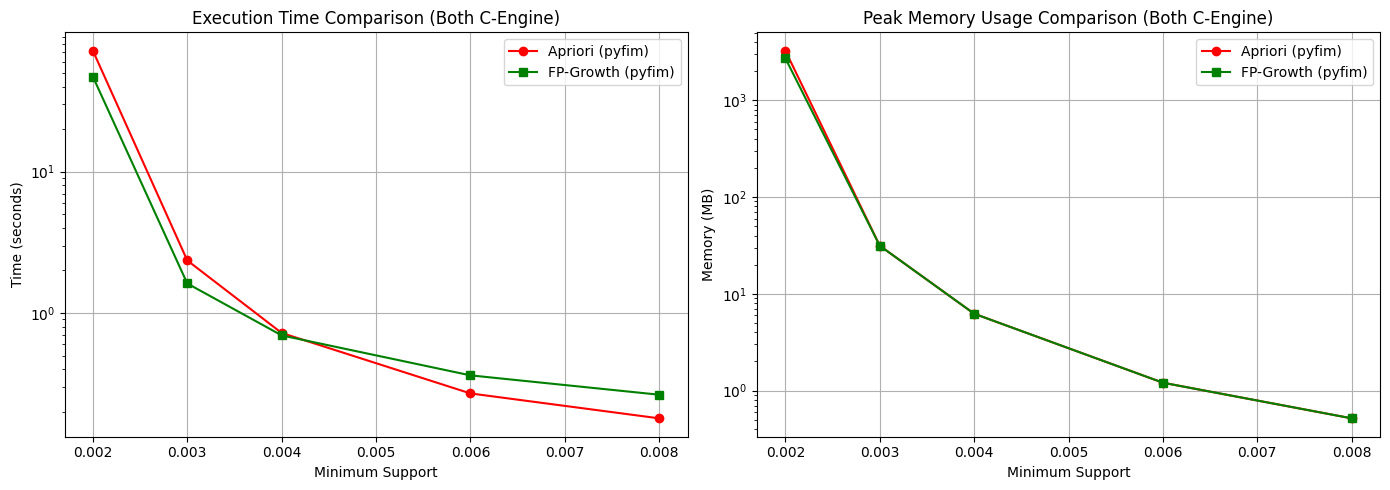

In [10]:
# --- SO SÁNH HIỆU NĂNG ---
import warnings
warnings.filterwarnings("ignore")
warnings.showwarning = lambda *args, **kwargs: None

import time
import psutil
import gc
import numpy as np
import tracemalloc
from fim import apriori as apriori_fim
from fim import fpgrowth as fpgrowth_fim
from mlxtend.frequent_patterns import fpgrowth, association_rules

process = psutil.Process(os.getpid())
N_RUNS = 5

def measure_pyfim(func, transactions, pyfim_supp, n_runs=N_RUNS):
    times = []
    mem_peaks = []
    for _ in range(n_runs):
        gc.collect()
        
        # Đo peak RSS trong quá trình chạy bằng tracemalloc để bắt delta Python
        # + psutil để lấy baseline, kết hợp cả hai
        mem_before = process.memory_info().rss
        tracemalloc.start()
        
        start = time.perf_counter()
        _ = func(transactions, target='s', supp=pyfim_supp)
        elapsed = time.perf_counter() - start
        
        mem_after = process.memory_info().rss
        _, traced_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        
        # Lấy max của cả hai phương pháp để không bỏ sót
        rss_delta = max(mem_after - mem_before, 0)
        mem_used = max(rss_delta, traced_peak) / 10**6  # MB
        # Đảm bảo luôn có giá trị tối thiểu để log scale không bị lỗi
        mem_used = max(mem_used, 0.01)
        
        times.append(elapsed)
        mem_peaks.append(mem_used)
    
    return np.median(times), np.median(mem_peaks)

min_supports = [0.002, 0.003, 0.004, 0.006, 0.008]

# ← PHẦN BỊ THIẾU: khởi tạo list trước vòng lặp
apriori_times, fpgrowth_times = [], []
apriori_mems, fpgrowth_mems = [], []

print("Đang chuẩn bị dữ liệu dạng List of Lists cho pyfim...")
transactions = []
for _, row in basket_sets.iterrows():
    item_list = row[row > 0].index.tolist()
    transactions.append(item_list)

print("Đang chạy benchmark...")
for min_sup in min_supports:
    pyfim_supp = min_sup * 100

    apriori_time, apriori_mem = measure_pyfim(apriori_fim, transactions, pyfim_supp)
    gc.collect()
    fpgrowth_time, fpgrowth_mem = measure_pyfim(fpgrowth_fim, transactions, pyfim_supp)

    apriori_times.append(apriori_time)
    apriori_mems.append(apriori_mem)
    fpgrowth_times.append(fpgrowth_time)
    fpgrowth_mems.append(fpgrowth_mem)

    print(f"min_sup={min_sup:.3f} | Apriori: {apriori_time:.4f}s / {apriori_mem:.2f}MB | FP-Growth: {fpgrowth_time:.4f}s / {fpgrowth_mem:.2f}MB")

# --- VẼ BIỂU ĐỒ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(min_supports, apriori_times, marker='o', label='Apriori (pyfim)', color='red')
axes[0].plot(min_supports, fpgrowth_times, marker='s', label='FP-Growth (pyfim)', color='green')
axes[0].set_title('Execution Time Comparison (Both C-Engine)')
axes[0].set_xlabel('Minimum Support')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(min_supports, apriori_mems, marker='o', label='Apriori (pyfim)', color='red')
axes[1].plot(min_supports, fpgrowth_mems, marker='s', label='FP-Growth (pyfim)', color='green')
axes[1].set_title('Peak Memory Usage Comparison (Both C-Engine)')
axes[1].set_xlabel('Minimum Support')
axes[1].set_ylabel('Memory (MB)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 6. Association Rule Generation
Sử dụng tập mục phổ biến đã tìm được để sinh các luật kết hợp. Các luật được lọc dựa trên chỉ số Lift > 1 để đảm bảo tính ý nghĩa.

In [11]:
# --- RÚT TRÍCH LUẬT KẾT HỢP (ASSOCIATION RULES) (DM_C6) ---
import warnings
warnings.filterwarnings("ignore")
warnings.showwarning = lambda *args, **kwargs: None


print("\nĐang sinh luật kết hợp...")
# Gọi fpgrowth của mlxtend (vì không có hậu tố _fim, an toàn 100%)
frequent_itemsets = fpgrowth(basket_sets, min_support=0.02, use_colnames=True)
# Tạo ra các luật kết hợp từ frequent itemsets
# Rút trích các luật có độ tin cậy (confidence) tối thiểu 50% trước
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

# Sau đó mới giữ lại các luật có tương quan dương (lift > 1)
rules = rules[rules['lift'] > 1.0]

# --- POST-PROCESSING: Phục hồi tên sản phẩm để dễ đọc ---
# Đổi frozenset StockCode sang tên Description
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join([item_name_mapping.get(item, item) for item in x]))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join([item_name_mapping.get(item, item) for item in x]))

# Sắp xếp như bạn đã làm
rules = rules.sort_values(['confidence', 'lift'], ascending=[False, False])

# --- BUSINESS-READY OUTPUT FORMATTING ---
print("Top 10 Recommendations based on Association Rules:\n" + "-"*80)
for index, row in rules.head(10).iterrows():
    antecedent = row['antecedents']
    consequent = row['consequents']
    conf_pct = round(row['confidence'] * 100, 2)
    supp_pct = round(row['support'] * 100, 2)
    lift_val = round(row['lift'], 2)
    
    print(f"IF a customer buys: [{antecedent}]")
    print(f"Then the best item to recommend is: [{consequent}]")
    print(f"Confidence: {conf_pct}% | Support: {supp_pct}% | Lift: {lift_val}x")
    print("-" * 80)


Đang sinh luật kết hợp...
Top 10 Recommendations based on Association Rules:
--------------------------------------------------------------------------------
IF a customer buys: [PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER]
Then the best item to recommend is: [GREEN REGENCY TEACUP AND SAUCER]
Confidence: 90.29% | Support: 2.64% | Lift: 18.06x
--------------------------------------------------------------------------------
IF a customer buys: [GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER]
Then the best item to recommend is: [ROSES REGENCY TEACUP AND SAUCER]
Confidence: 85.44% | Support: 2.64% | Lift: 16.68x
--------------------------------------------------------------------------------
IF a customer buys: [PINK REGENCY TEACUP AND SAUCER]
Then the best item to recommend is: [GREEN REGENCY TEACUP AND SAUCER]
Confidence: 82.08% | Support: 3.09% | Lift: 16.42x
--------------------------------------------------------------------------------
IF a custo

In [12]:
# Kiểm tra chất lượng rules
print(f"Tổng số luật rút trích được: {len(rules)}")
print(f"Số luật bị trùng lặp: {rules.duplicated(subset=['antecedents','consequents']).sum()}")

Tổng số luật rút trích được: 130
Số luật bị trùng lặp: 3


Đang vẽ biểu đồ Visualization cho các luật kết hợp...


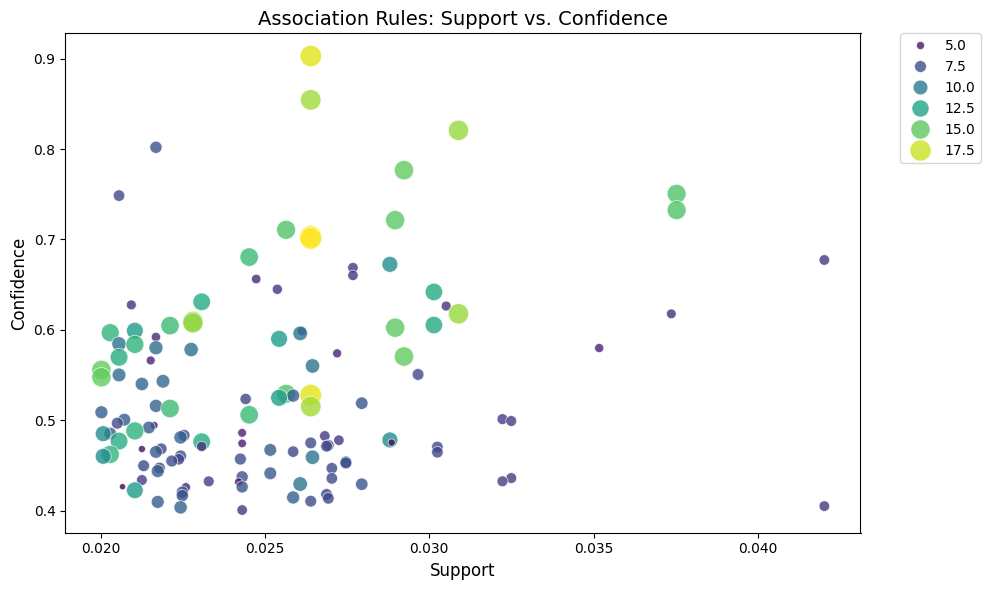

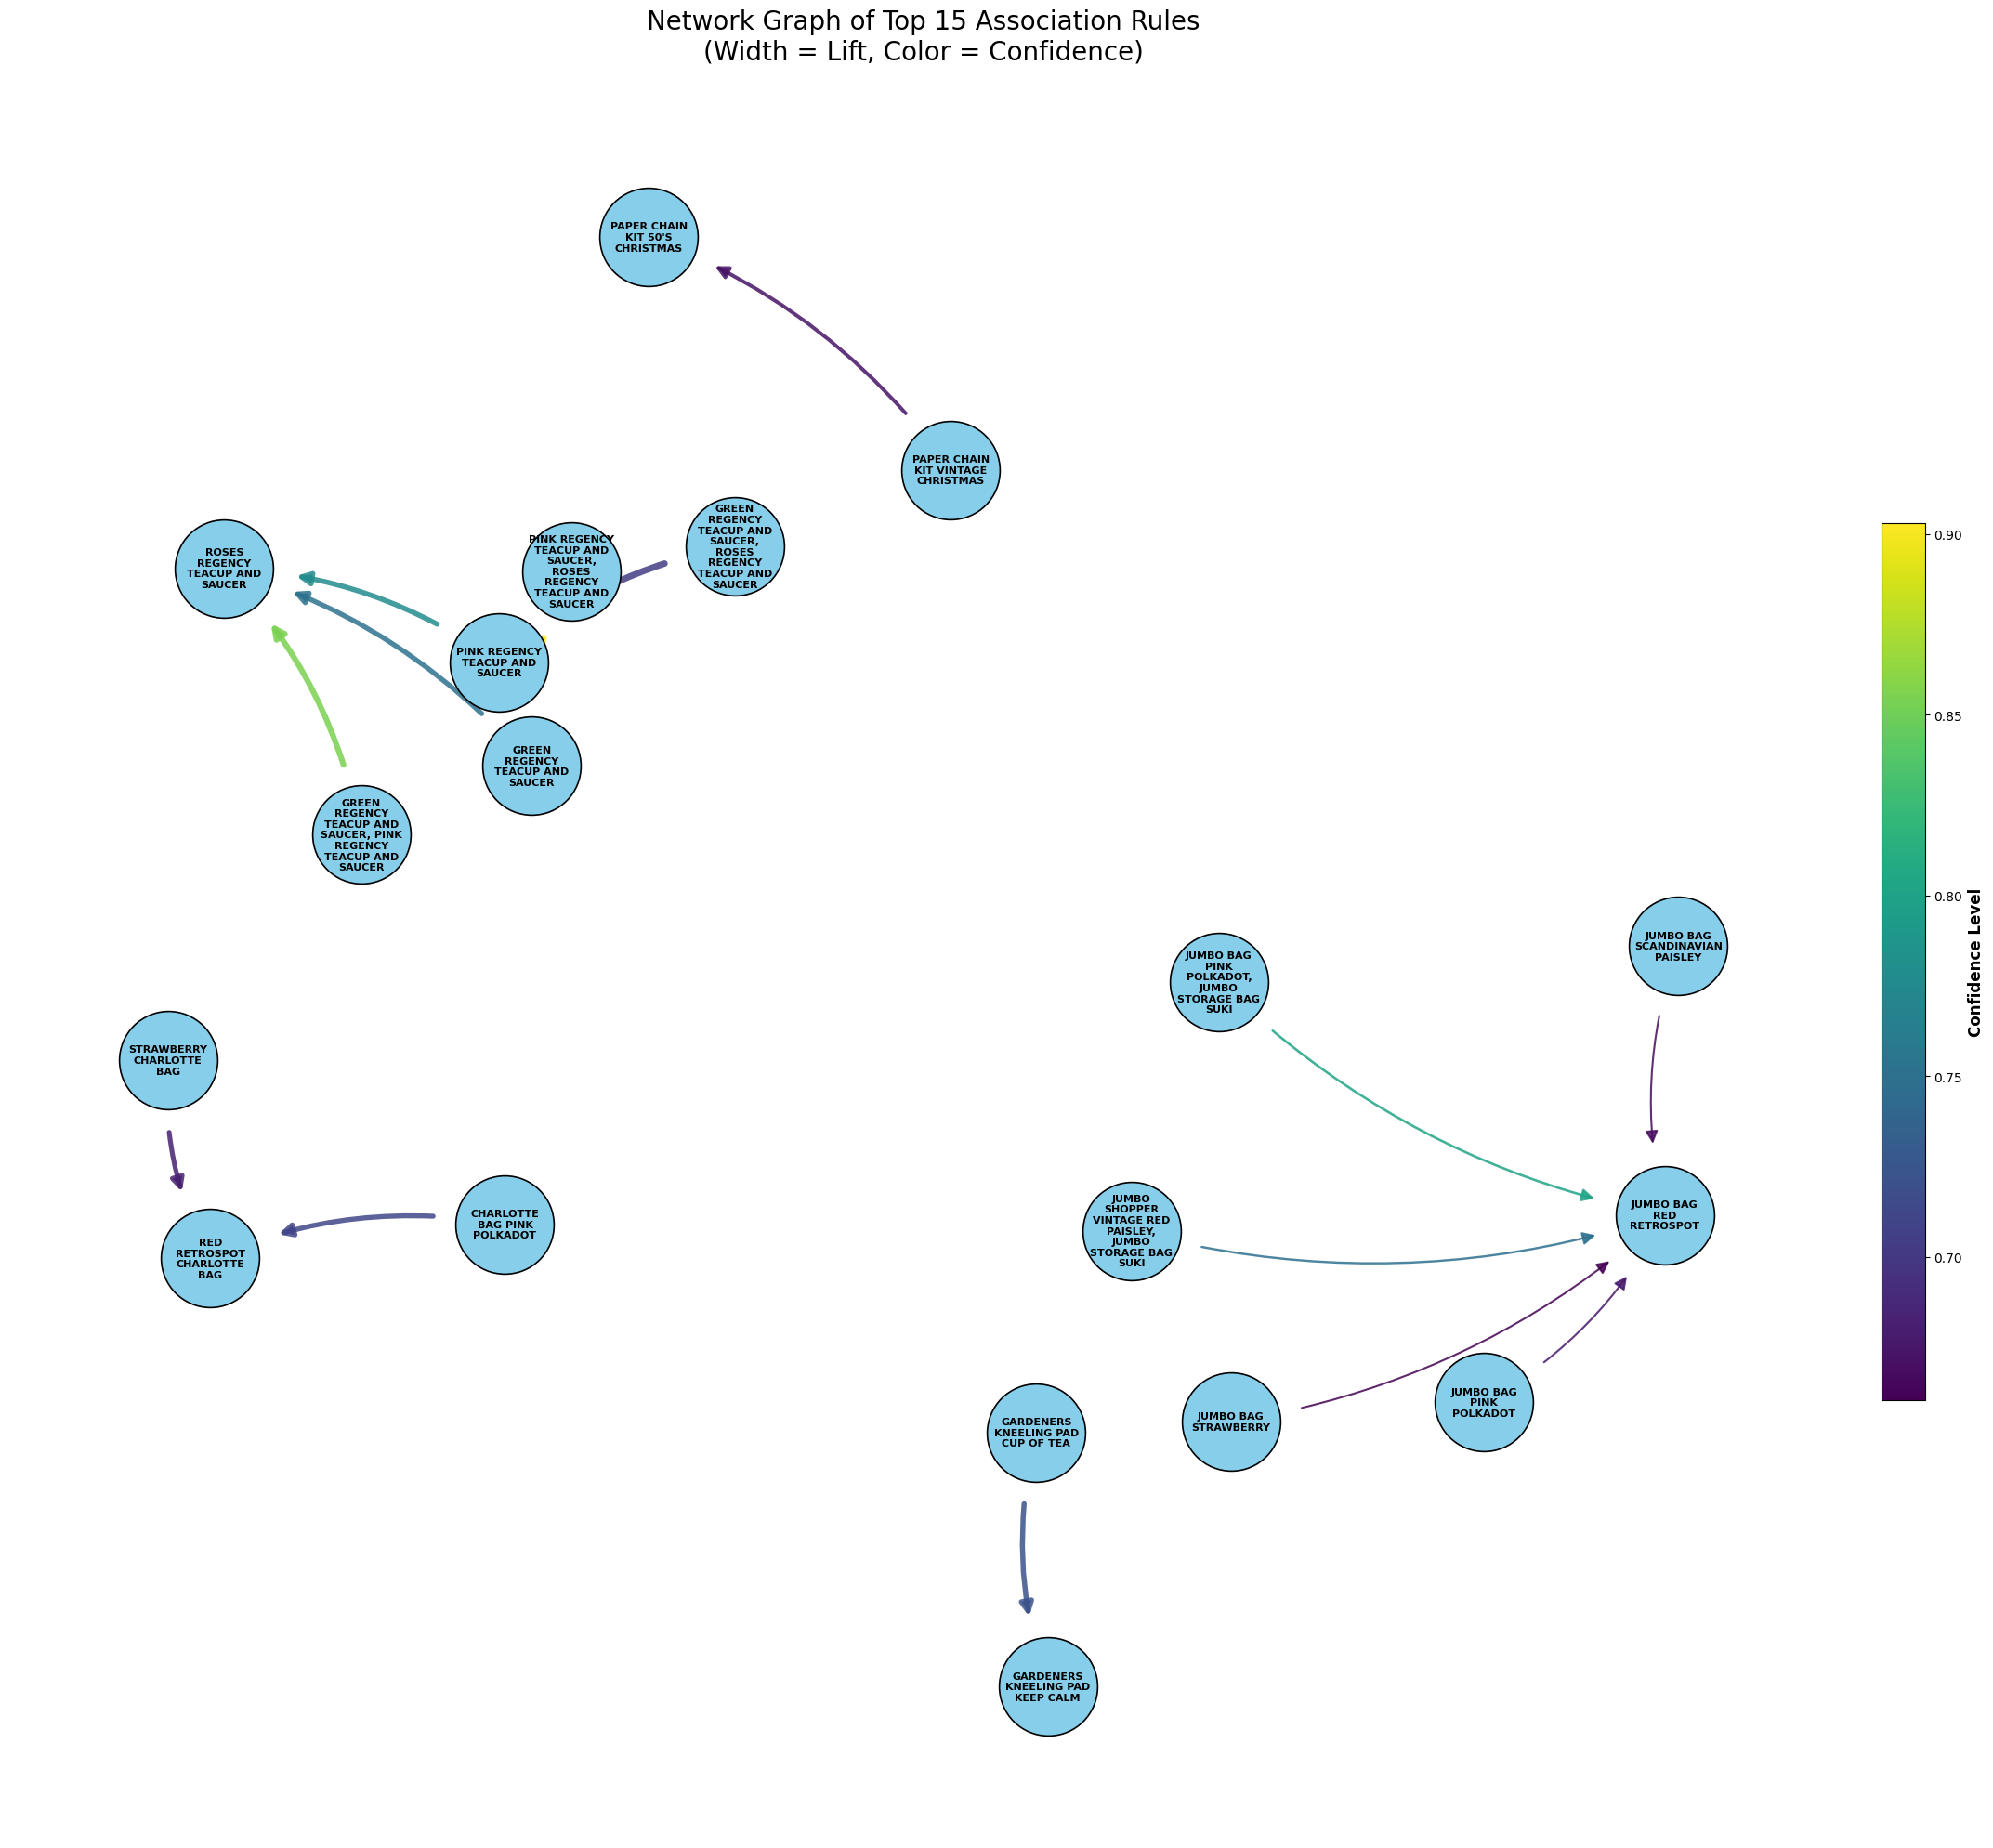

In [13]:
import warnings
warnings.filterwarnings("ignore")
warnings.showwarning = lambda *args, **kwargs: None
import networkx as nx
import textwrap
import matplotlib.pyplot as plt
import numpy as np


print("Đang vẽ biểu đồ Visualization cho các luật kết hợp...")

# 1. Scatter Plot: Support vs Confidence (Bong bóng to nhỏ tùy vào Lift)
plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", 
                palette="viridis", data=rules, sizes=(20, 250), alpha=0.8)
plt.title('Association Rules: Support vs. Confidence', fontsize=14)
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
# Đưa Legend ra ngoài cho gọn
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()


# --- 1. LỌC LẤY 15 CẶP LUẬT ---
unique_edges = set()
filtered_rules = []
for idx, row in rules.iterrows():
    edge_pair = frozenset([row['antecedents'], row['consequents']])
    if edge_pair not in unique_edges:
        unique_edges.add(edge_pair)
        filtered_rules.append(row)
    if len(filtered_rules) == 15:
        break
top_rules = pd.DataFrame(filtered_rules)

G = nx.DiGraph()
for idx, row in top_rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'],
               weight=row['lift'],
               confidence=row['confidence'])
pos = nx.spring_layout(
    G,
    k=4.5,          # khoảng cách lý tưởng giữa các node (tăng nếu vẫn bị overlap)
    iterations=200,  # số lần lặp để tối ưu vị trí
    seed=42          # seed cố định để kết quả ổn định; thử 0, 7, 99 nếu layout xấu
)

# --- 3. CHUẨN BỊ ---
size_of_node = 5800   # Giảm node size để giảm overlap và để arrow rõ hơn
node_radius_pt = np.sqrt(size_of_node / np.pi) + 8  # bán kính node (dùng cho margin)

wrapped_labels = {node: '\n'.join(textwrap.wrap(node, width=12)) for node in G.nodes()}

edges = list(G.edges())
lifts = [G[u][v]['weight'] for u, v in edges]
confidences = [G[u][v]['confidence'] for u, v in edges]

min_lift, max_lift = min(lifts), max(lifts)
if max_lift > min_lift:
    edge_widths = [1.5 + 3.5 * (l - min_lift) / (max_lift - min_lift) for l in lifts]
else:
    edge_widths = [2.0] * len(lifts)

# --- 4. VẼ ---
fig, ax = plt.subplots(figsize=(24, 20))  # tăng kích thước hình
# Vẽ edges — thêm min_source/target_margin để arrow không đâm vào node
nx.draw_networkx_edges(
    G, pos,
    ax=ax,
    node_size=size_of_node,
    width=edge_widths,
    edge_color=confidences,
    edge_cmap=plt.cm.viridis,
    arrows=True,
    arrowsize=20,
    alpha=0.85,
    connectionstyle='arc3, rad=0.15',
    min_source_margin=node_radius_pt + 5,   # đẩy điểm bắt đầu ra khỏi viền node nguồn
    min_target_margin=node_radius_pt + 5,   # đẩy mũi tên dừng trước khi chạm node đích
)

# Vẽ nodes
nx.draw_networkx_nodes(
    G, pos,
    ax=ax,
    node_size=size_of_node,
    node_color='skyblue',
    edgecolors='black',
    linewidths=1.2,
    alpha=1.0
)
# Vẽ labels
nx.draw_networkx_labels(
    G, pos,
    ax=ax,
    labels=wrapped_labels,
    font_size=8,
    font_family="sans-serif",
    font_weight='bold'
)

# --- 5. COLORBAR ---
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=min(confidences), vmax=max(confidences))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Confidence Level', fontsize=12, weight='bold')

ax.set_title(
    'Network Graph of Top 15 Association Rules\n(Width = Lift, Color = Confidence)',
    fontsize=20, pad=20
)
ax.axis('off')
plt.tight_layout()
plt.savefig('network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

### Tổng kết kết quả
- **Luật tiêu biểu:** {PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER} $\rightarrow$ {GREEN REGENCY TEACUP AND SAUCER} (Lift = 18.06).
- **Ý nghĩa ngắn:** Khách hàng mua ấm trà hồng có xác suất rất cao sẽ mua thêm màu xanh. 
- **Gợi ý:** Nên thiết kế các combo sản phẩm cùng loại nhưng khác màu sắc để tăng doanh thu.